# AI Classification of Occupation Codes

## Prediction of `SemelMishlachSofi`

### Project Overview

This notebook develops a data science solution for predicting the final occupation code, `SemelMishlachSofi`, based on survey response data.

The dataset includes structured and free-text variables that describe the respondent's workplace, job title, type of work, task description, education, age, and additional employment-related information. The target variable, `SemelMishlachSofi`, represents the final manually assigned occupation code.

The main goal is to build a machine learning model that can learn patterns from manually coded examples and predict the final occupation code for new survey responses.

### Analysis and Modeling Approach

The notebook follows several main stages:

1. **Data loading and initial inspection**
   The Excel dataset and metadata are loaded, and the structure of the data is inspected.

2. **Data cleaning**
   Rows with missing target values are removed, partial or unknown target codes containing `X` are excluded, and duplicate rows are dropped.

3. **Coding-consistency analysis**
   Before modeling, the notebook checks whether specific survey variables or combinations of variables are consistently associated with the same occupation code.
   This helps identify which fields are most informative and whether rule-based patterns exist in the manual coding process.

4. **Feature engineering**
   Key occupational text fields are combined into a single `combined_text` feature. Additional categorical and numeric variables are also prepared for modeling.

5. **Machine learning model**
   A text-based classification pipeline is built using TF-IDF features and Logistic Regression. The model predicts the full 4-digit occupation code.

6. **Evaluation**
   Model performance is evaluated using a train/test split. In addition, cross-validation is performed at the 2-digit occupation-code level to provide a more stable evaluation.

7. **Rule-based baseline and hybrid model**
   A rule-based baseline is learned only from the training data to avoid data leakage.
   A hybrid approach is also tested: when a reliable rule exists, the rule prediction is used; otherwise, the machine learning prediction is used.

### Important Methodological Note

The rule-based component is used carefully to avoid target leakage.
Rules are learned only from the training set and then evaluated on the test set. This ensures that the rule-based baseline and hybrid model are evaluated in a realistic way.

### Expected Output

The notebook produces:

* cleaned and prepared modeling data,
* coding-consistency summaries,
* machine learning model performance,
* rule-based baseline performance,
* hybrid model performance,
* and a CSV file containing prediction results.


In [29]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_recall_fscore_support,
                             confusion_matrix, ConfusionMatrixDisplay)


import matplotlib.pyplot as plt


pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

## Step 2: Load data
In Colab: upload `DUMMY_DATASET.xlsx` to the same folder.

In [11]:
#%% Step 2: Upload and load data

from google.colab import files

print("Please upload the file: DUMMY_DATASET.xlsx")

uploaded = files.upload()

file_path = "DUMMY_DATASET.xlsx"

excel_file = pd.ExcelFile(file_path)

print("Sheet names:", excel_file.sheet_names)

df = pd.read_excel(file_path, sheet_name="Survey Dataset")
metadata = pd.read_excel(file_path, sheet_name="Metadata")

print("Dataset shape:", df.shape)
print("Metadata shape:", metadata.shape)

target_col = "SemelMishlachSofi"

# Inspect columns

df.columns

# Print all column names line by line
for col in df.columns:
    print(col)

# Step 2.2: Basic dataset information

df.info()
# View random rows
display(df.sample(5, random_state=42))

Please upload the file: DUMMY_DATASET.xlsx


Saving DUMMY_DATASET.xlsx to DUMMY_DATASET (2).xlsx
Sheet names: ['Survey Dataset', 'Metadata']
Dataset shape: (201, 18)
Metadata shape: (18, 16384)
ID
YeshuvAvoda
ShemAvoda
SugAvoda
ShemMachlaka
SugMachlaka
EzoAvoda
TeurPeula
TeurTafkid
MenahelEtMi
MaamadAvoda
MakorSachar
TeudaGvoha
shnotlimud
Gil
TarichHathala
SemelAnafSofi
SemelMishlachSofi
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201 entries, 0 to 200
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ID                 200 non-null    float64       
 1   YeshuvAvoda        200 non-null    object        
 2   ShemAvoda          200 non-null    object        
 3   SugAvoda           175 non-null    object        
 4   ShemMachlaka       136 non-null    object        
 5   SugMachlaka        66 non-null     object        
 6   EzoAvoda           193 non-null    object        
 7   TeurPeula          64 non-null     object        

,ID,YeshuvAvoda,ShemAvoda,SugAvoda,ShemMachlaka,SugMachlaka,EzoAvoda,TeurPeula,TeurTafkid,MenahelEtMi,MaamadAvoda,MakorSachar,TeudaGvoha,shnotlimud,Gil,TarichHathala,SemelAnafSofi,SemelMishlachSofi
95,96.0,ירושלים,בית חולים הדסה עין כרם,טיפול בחולים,רדיואתרפיה,טיפול בחולי סרטן,טכנאית רדיותרפיה,"כנ""ל","כנ""ל",NaN,1.0,1.0,6.0,22.0,55.0,2022-07-01,8610,3211
15,16.0,עפולה,סופר פארם,מכירת קוסמטיקה,קוסמטיקה וטיפוח,NaN,יועצת יופי לאנשים,מסבירה לאנשים לגבי מוצרים של חברת LOREAL,NaN,NaN,1.0,1.0,3.0,13.0,32.0,2022-04-01,4772,5223
30,31.0,ירושלים,סולל בונה,אתר בניה אצל קבלן,עבודות חשמל,NaN,התקנת חשמל בדירות חדשות,עוזר לחשמלאי,NaN,NaN,1.0,2.0,3.0,12.0,22.0,2022-12-01,4323,7414
158,159.0,תל אביב,קניון עזריאלי,חנות למכירת בגדים,NaN,NaN,מוכרת,NaN,NaN,NaN,1.0,1.0,3.0,12.0,25.0,2011-11-01,4770,5223
128,129.0,מודיעין,משרד הפנים,קבלת קהל,תמיכה בלקוחות,"כנ""ל",קבלת קהל,קבלת קהל,NaN,NaN,1.0,1.0,4.0,12.0,52.0,2022-06-06,8411,3354


## Step 3: Clean the data
- Drop rows with missing target.
- Normalize the code to string (strip trailing `.0`).
- Drop rows with `X` (partial coding the manual coders could not complete).
- Drop duplicate rows.

In [12]:
df_clean = df.copy()
df_clean = df_clean.dropna(subset=[target_col])

def normalize_code(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    if value.endswith(".0"):
        value = value[:-2]
    return value

df_clean[target_col] = df_clean[target_col].apply(normalize_code)

mask_x = df_clean[target_col].str.contains("X", na=False)
print("Rows with X in target:", int(mask_x.sum()))
df_clean = df_clean[~mask_x].copy()
df_clean = df_clean.drop_duplicates().copy()

print("Shape after cleaning:", df_clean.shape)
print("Target classes:", df_clean[target_col].nunique())

Rows with X in target: 9
Shape after cleaning: (191, 18)
Target classes: 59


## Step 3b: Visualize class imbalance
The target has many codes with very few examples each, the core data challenge.

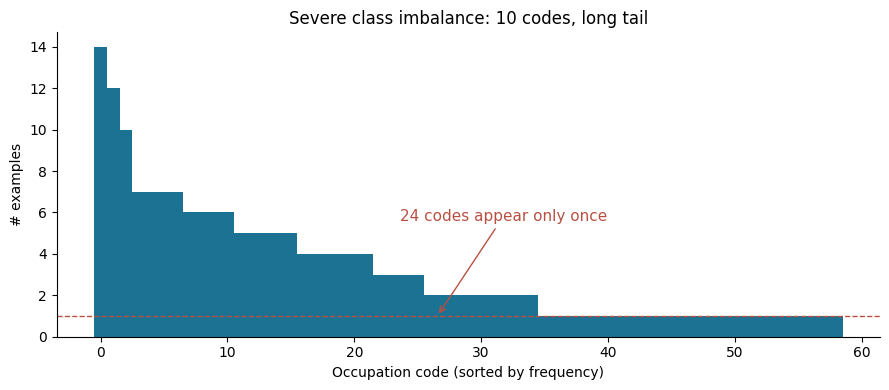

Total codes: 59 | Codes appearing only once: 24


In [30]:
# Count examples per occupation code, sorted from most to least frequent
code_counts = df_clean[target_col].value_counts()
n_singletons = int((code_counts == 1).sum())

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(code_counts)), code_counts.values, color="#1C7293", width=1.0)

# Reference line at y=1 (codes appearing only once)
ax.axhline(1, color="#B85042", linestyle="--", linewidth=1)
ax.annotate(
    f"{n_singletons} codes appear only once",
    xy=(len(code_counts) * 0.45, 1),
    xytext=(len(code_counts) * 0.40, code_counts.max() * 0.4),
    color="#B85042", fontsize=11,
    arrowprops=dict(arrowstyle="->", color="#B85042"),
)

ax.set_xlabel("Occupation code (sorted by frequency)")
ax.set_ylabel("# examples")
ax.set_title(f"Severe class imbalance: {code_counts.nunique()} codes, long tail")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Total codes: {len(code_counts)} | Codes appearing only once: {n_singletons}")

## Step 4: Coding-Consistency Analysis

Before building the prediction model, this step checks which feature combinations are consistently associated with a single final occupation code.

For each candidate feature combination, a combined key is created, such as:

`EzoAvoda | TeurPeula`

The dataset is then grouped by this key, and the following measures are calculated:

* **Support** — the number of rows with the same key.
* **Purity** — the share of the most common occupation code within that group.
* **Consistency** — whether the group maps to only one final occupation code.

This analysis helps identify which survey fields are most informative for predicting `SemelMishlachSofi`. Feature combinations with high support and high purity suggest that the manual coding process follows consistent patterns. These patterns can later guide feature engineering, support a rule-based baseline, or improve the final prediction model.


In [13]:
def clean_value(series):
    return (series.fillna("Missing").astype(str)
            .str.strip().str.replace(r"\s+", " ", regex=True))

candidate_rules = [
    ["EzoAvoda"], ["TeurTafkid"], ["TeurPeula"], ["SugAvoda"],
    ["ShemAvoda"], ["ShemMachlaka"], ["SugMachlaka"],
    ["EzoAvoda", "TeurPeula"], ["EzoAvoda", "TeurTafkid"], ["TeurTafkid", "TeurPeula"],
    ["SugAvoda", "EzoAvoda"], ["ShemAvoda", "EzoAvoda"], ["ShemAvoda", "TeurTafkid"],
    ["ShemAvoda", "SugAvoda", "EzoAvoda"], ["SugAvoda", "EzoAvoda", "TeurPeula"],
    ["EzoAvoda", "TeurTafkid", "TeurPeula"],
    ["ShemAvoda", "SugAvoda", "EzoAvoda", "TeurTafkid", "TeurPeula"],
]

candidate_rules = [cols for cols in candidate_rules if all(c in df_clean.columns for c in cols)]


def evaluate_coding_consistency(df, feature_cols, target_col):
    temp = df.copy()

    for col in feature_cols:
        temp[col] = clean_value(temp[col])

    temp["rule_key"] = temp[feature_cols].agg(" | ".join, axis=1)
    temp["target_code"] = temp[target_col].astype(str)

    rule_table = (temp.groupby("rule_key").agg(
        n_rows=("target_code", "size"),
        n_unique_codes=("target_code", "nunique"),
        predicted_code=("target_code", lambda x: x.value_counts().index[0]),
        predicted_code_count=("target_code", lambda x: x.value_counts().iloc[0]),
    ).reset_index())

    rule_table["feature_combination"] = " + ".join(feature_cols)
    rule_table["purity"] = rule_table["predicted_code_count"] / rule_table["n_rows"]

    return rule_table


rules_df = pd.concat(
    [evaluate_coding_consistency(df_clean, cols, target_col) for cols in candidate_rules],
    ignore_index=True
)

# A rule is considered useful only if it appears enough times and is highly consistent.
# min_support = 3 means that a key must appear in at least 3 rows.
# This avoids treating one-time or two-time examples as reliable rules.
min_support = 3

# min_purity = 0.9 means that at least 90% of the rows with the same key
# must have the same most common occupation code.
# This keeps only rules that are strongly associated with one code.
min_purity = 0.9

rules_df["is_useful_rule"] = (
    (rules_df["n_rows"] >= min_support) &
    (rules_df["purity"] >= min_purity)
)

combination_quality = (
    rules_df.groupby("feature_combination").agg(
        n_unique_keys=("rule_key", "count"),
        n_useful_rules=("is_useful_rule", "sum"),
        total_rows=("n_rows", "sum"),
        mean_purity=("purity", "mean"),
        max_support=("n_rows", "max"),
    )
    .reset_index()
    .sort_values(["n_useful_rules", "mean_purity"], ascending=[False, False])
)

display(combination_quality)

,feature_combination,n_unique_keys,n_useful_rules,total_rows,mean_purity,max_support
2,EzoAvoda + TeurTafkid,86,23,191,0.971899,7
0,EzoAvoda,83,23,191,0.970884,7
3,EzoAvoda + TeurTafkid + TeurPeula,89,22,191,0.982210,7
1,EzoAvoda + TeurPeula,86,22,191,0.973837,7
11,SugAvoda + EzoAvoda,105,17,191,0.992857,7
12,SugAvoda + EzoAvoda + TeurPeula,106,16,191,0.992925,7
10,SugAvoda,77,15,191,0.943277,23
9,ShemMachlaka,60,14,191,0.939651,62
7,ShemAvoda + SugAvoda + EzoAvoda + TeurTafkid + TeurPeula,128,12,191,0.998047,7
6,ShemAvoda + SugAvoda + EzoAvoda,127,12,191,0.998031,7


### Inspect the most reliable individual rules

In [14]:
useful_rules = (rules_df.query("n_rows >= @min_support").query("purity >= @min_purity")
                .sort_values(["purity", "n_rows"], ascending=[False, False]))
display(useful_rules[["feature_combination", "rule_key", "n_rows",
                      "predicted_code", "purity"]].head(25))

,feature_combination,rule_key,n_rows,predicted_code,purity
24,EzoAvoda,טבח,7,5120,1.0
78,EzoAvoda,שומר בבית הספר,7,5414,1.0
140,SugAvoda,בית ספר יסודי,7,5414,1.0
152,SugAvoda,חנות למכירת בגדים,7,5223,1.0
259,ShemAvoda,משטרה,7,5412,1.0
345,ShemMachlaka,שמירה,7,5414,1.0
409,EzoAvoda + TeurPeula,טבח | Missing,7,5120,1.0
466,EzoAvoda + TeurPeula,שומר בבית הספר | Missing,7,5414,1.0
496,EzoAvoda + TeurTafkid,טבח | Missing,7,5120,1.0
552,EzoAvoda + TeurTafkid,שומר בבית הספר | Missing,7,5414,1.0


# Build a clean summary table of the most informative field combinations

In [32]:
summary = combination_quality.set_index("feature_combination")

rows_to_show = {
    "EzoAvoda": "EzoAvoda (which work)",
    "EzoAvoda + TeurPeula": "EzoAvoda + TeurPeula",
    "ShemAvoda + SugAvoda + EzoAvoda + TeurTafkid + TeurPeula": "+ 3 more fields",
    "ShemMachlaka": "ShemMachlaka (dept.)",
}

notes = {
    "EzoAvoda": "Strongest single field",
    "EzoAvoda + TeurPeula": "Best purity-vs-coverage balance \u2192 used in hybrid",
    "ShemAvoda + SugAvoda + EzoAvoda + TeurTafkid + TeurPeula": "Near-perfect purity, but keys fragment (overfitting)",
    "ShemMachlaka": "High coverage, lower purity",
}

display_rows = []
for key, label in rows_to_show.items():
    if key in summary.index:
        r = summary.loc[key]
        display_rows.append({
            "Field combination": label,
            "Useful rules": int(r["n_useful_rules"]),
            "Mean purity": round(r["mean_purity"], 3),
            "Note": notes[key],
        })

summary_table = pd.DataFrame(display_rows)
display(summary_table)

,Field combination,Useful rules,Mean purity,Note
0,EzoAvoda (work area),23,0.971,Strongest single field
1,EzoAvoda + TeurPeula,22,0.974,Best purity-vs-coverage balance → used in hybrid
2,+ 3 more fields,12,0.998,"Near-perfect purity, but keys fragment (overfitting)"
3,ShemMachlaka (dept.),14,0.940,"High coverage, lower purity"


## Step 5: Feature engineering
- **Combined text**: all occupational description fields merged into one column for TF-IDF.
- **Categorical + numeric**: education, status, age, economic branch, etc.


In [15]:
occupation_text_cols = ["ShemAvoda","SugAvoda","ShemMachlaka","SugMachlaka",
                        "EzoAvoda","TeurPeula","TeurTafkid"]
occupation_text_cols = [c for c in occupation_text_cols if c in df_clean.columns]
temp_text = df_clean[occupation_text_cols].copy()
for c in occupation_text_cols:
    temp_text[c] = clean_value(temp_text[c])
df_clean["combined_text"] = temp_text.agg(" ".join, axis=1)

categorical_cols = ["SemelAnafSofi","TeudaGvoha","MaamadAvoda","MakorSachar","MenahelEtMi"]
categorical_cols = [c for c in categorical_cols if c in df_clean.columns]
numeric_cols = [c for c in ["Gil","shnotlimud"] if c in df_clean.columns]

# force categorical columns to clean strings
def normalize_categorical(value):
    if pd.isna(value):
        return "Missing"
    value = str(value).strip()
    if value.endswith(".0"):
        value = value[:-2]
    return value

for c in categorical_cols:
    df_clean[c] = df_clean[c].apply(normalize_categorical)

model_features = ["combined_text"] + categorical_cols + numeric_cols
print("Model features:", model_features)
display(df_clean[[target_col, "combined_text"]].head())

Model features: ['combined_text', 'SemelAnafSofi', 'TeudaGvoha', 'MaamadAvoda', 'MakorSachar', 'MenahelEtMi', 'Gil', 'shnotlimud']


,SemelMishlachSofi,combined_text
0,2120,"למ""ס איסוף, עיבוד ופרסום נתונים מיקרו כלכלה טיפול בנתוני מיקרו סגן מנהל אגף כנ""ל סגן מנהל אגף"
1,3311,"בית חולים הדסה עין כרם טיפול בחולים רדיואתרפיה טיפול בחולי סרטן טכנאית רדיותרפיה כנ""ל כנ""ל"
2,3512,"קריית הממשלה מתן שירות למשתמשים באתר GOV תמיכה בלקוחות כנ""ל נותנת תמיכה ללקוחות שמבקשים עזרה מסבירה איך להשתמש בשירו..."
3,5414,משרד החינוך בית ספר יסודי שמירה Missing שומר בבית הספר Missing Missing
4,5322,"אמיר כהן מטפל בקשיש במשפחה Missing Missing מטפל בקשיש נותן אוכל, עוזר בניקיון בית, עוזר להתרחץ Missing"


## Step 6: Build the pipeline factory

In [16]:
def build_model():
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

    transformers = [("text", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=1), "combined_text")]
    if categorical_cols:
        transformers.append(("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", ohe)]), categorical_cols))
    if numeric_cols:
        transformers.append(("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False))]), numeric_cols))

    preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")
    return Pipeline([("preprocessor", preprocessor),
                     ("classifier", LogisticRegression(max_iter=3000, class_weight="balanced", solver="lbfgs"))])

## Step 7: Train/test split and training (full 4-digit target)
With 59 classes and few rows, single-split accuracy is unstable, see Step 8.

In [17]:
y = df_clean[target_col]
train_df, test_df = train_test_split(df_clean, test_size=0.25, random_state=42)
X_train, y_train = train_df[model_features], train_df[target_col]
X_test, y_test = test_df[model_features], test_df[target_col]

print("Train size:", X_train.shape, "| Test size:", X_test.shape)
print("Classes in train:", y_train.nunique(), "| Classes in test:", y_test.nunique())

model = build_model()
model.fit(X_train, y_train)
print("Model training completed.")

y_pred = pd.Series(model.predict(X_test), index=test_df.index)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"[4-digit] single split test accuracy: {test_accuracy:.3f}")

Train size: (143, 8) | Test size: (48, 8)
Classes in train: 53 | Classes in test: 27
Model training completed.
[4-digit] single split test accuracy: 0.833


### Classification report and prediction inspection

In [18]:
report = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
display(pd.DataFrame(report).T)

preds = test_df[[target_col]].copy()
preds["predicted_code"] = y_pred.values
preds["is_correct"] = preds[target_col].astype(str) == preds["predicted_code"].astype(str)
preds["combined_text"] = test_df["combined_text"].values
display(preds.head(20))

,precision,recall,f1-score,support
1212,0.000000,0.000000,0.000000,1.000000
1221,0.000000,0.000000,0.000000,1.000000
1330,0.000000,0.000000,0.000000,0.000000
1345,0.000000,0.000000,0.000000,0.000000
2120,0.666667,1.000000,0.800000,2.000000
2262,0.500000,1.000000,0.666667,1.000000
2330,0.000000,0.000000,0.000000,1.000000
2411,0.000000,0.000000,0.000000,1.000000
2511,0.333333,1.000000,0.500000,1.000000
2512,1.000000,0.500000,0.666667,2.000000


,SemelMishlachSofi,predicted_code,is_correct,combined_text
159,7127,7127,True,אדרים קבלן בנייה התקנת מזגנים Missing התקנת מזגנים בדירות חדשות טכנאי מזגנים Missing
78,5223,5223,True,סופר פארם מכירת קוסמטיקה קוסמטיקה וטיפוח Missing יועצת יופי לאנשים מסבירה לאנשים לגבי מוצרים של חברת LOREAL Missing
166,7414,5222,False,אוסם ייצור חטיפים עבודות חשמל Missing טיפול במערכות חשמל בצפעל Missing Missing
69,3122,3122,True,אינטל ייצור צ'יפים למחשבים חדר נקי Missing עובד בחדר נקי מפקח על תהליך ייצור צ'יפים Missing
63,2120,2120,True,"למ""ס איסוף, עיבוד ופרסום נתונים מאקרו כלכלה טיפול בנתוני מאקרו מנהל אגף כנ""ל סגן מנהל אגף"
15,5223,5223,True,סופר פארם מכירת קוסמטיקה קוסמטיקה וטיפוח Missing יועצת יופי לאנשים מסבירה לאנשים לגבי מוצרים של חברת LOREAL Missing
9,2514,2514,True,"EMILIO הייטק, פיתוח תוכנה Missing Missing מתכנת Missing Missing"
16,5142,5142,True,קוסמטיקאית עצמאית Missing Missing Missing קוסמטיקאית Missing Missing
134,2262,2262,True,סופרפארם רוקח רוקח רוקח רוקח Missing Missing
131,5414,5414,True,משרד החינוך בית ספר יסודי שמירה Missing שומר בבית הספר Missing Missing


## Step 8: Reliable evaluation via Cross-Validation (2-digit level)
On classes with enough samples. This is the only reliable metric here, a single split over 59 classes is misleading.

In [19]:
df_clean["target_2digit"] = df_clean[target_col].str[:2]
filt = df_clean.groupby("target_2digit").filter(lambda x: len(x) >= 5)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(build_model(), filt[model_features], filt["target_2digit"],
                            cv=skf, scoring="accuracy")
print(f"[2-digit] 5-fold CV accuracy: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
print("Folds:", np.round(cv_scores, 3))

[2-digit] 5-fold CV accuracy: 0.870 +/- 0.035
Folds: [0.871 0.806 0.871 0.903 0.9  ]


## Step 8b: Readable evaluation metrics
A 59x59 confusion matrix is unreadable and per-class scores are meaningless with ~1 test row per class. Instead I choose to report:
- **Aggregated precision/recall/F1** (macro and weighted) rather than the full per-class table.
- **Top-k accuracy** - how often the correct code is in the model's top 3 or 5 guesses (how a real coding-assistance tool is used).
- **A confusion matrix at the 1-digit classification major-group level** (8x8) - readable, and shows which broad occupation groups get confused.

Macro     -> precision: 0.642 | recall: 0.667 | F1: 0.639
Weighted  -> precision: 0.821 | recall: 0.833 | F1: 0.813
Top-3 accuracy: 0.833
Top-5 accuracy: 0.854

Major-group (1-digit) accuracy: 0.938


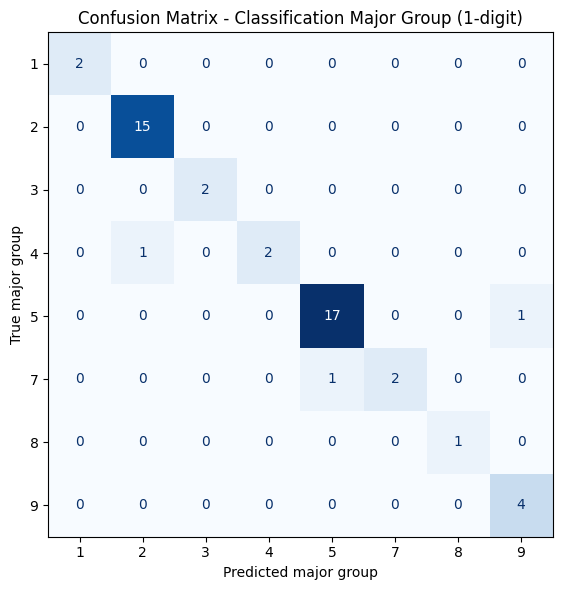

In [23]:
# Aggregated precision / recall / F1
for avg in ["macro", "weighted"]:
    p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average=avg, zero_division=0)
    print(f"{avg.capitalize():9s} -> precision: {p:.3f} | recall: {r:.3f} | F1: {f:.3f}")

# Top-k accuracy
classifier = model.named_steps["classifier"]
if hasattr(classifier, "predict_proba"):
    y_proba = model.predict_proba(X_test)
    classes = classifier.classes_
    y_test_str = y_test.astype(str).values
    for k in [3, 5]:
        topk_idx = np.argsort(y_proba, axis=1)[:, -k:]
        topk_codes = classes[topk_idx].astype(str)
        hits = [true in row for true, row in zip(y_test_str, topk_codes)]
        print(f"Top-{k} accuracy: {np.mean(hits):.3f}")

# Confusion matrix at the 1-digit classification major-group level
y_test_major = y_test.astype(str).str[0]
y_pred_major = y_pred.astype(str).str[0]
labels_major = sorted(set(y_test_major) | set(y_pred_major))
cm = confusion_matrix(y_test_major, y_pred_major, labels=labels_major)

major_acc = (y_test_major.values == y_pred_major.values).mean()
print(f"\nMajor-group (1-digit) accuracy: {major_acc:.3f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_major)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix - Classification Major Group (1-digit)")
ax.set_xlabel("Predicted major group")
ax.set_ylabel("True major group")
plt.tight_layout()
plt.show()

## Step 8c: Accuracy across the ISCO hierarchy levels
Comparing accuracy at the full 4-digit code, the 2-digit sub-major group, and the 1-digit major group.

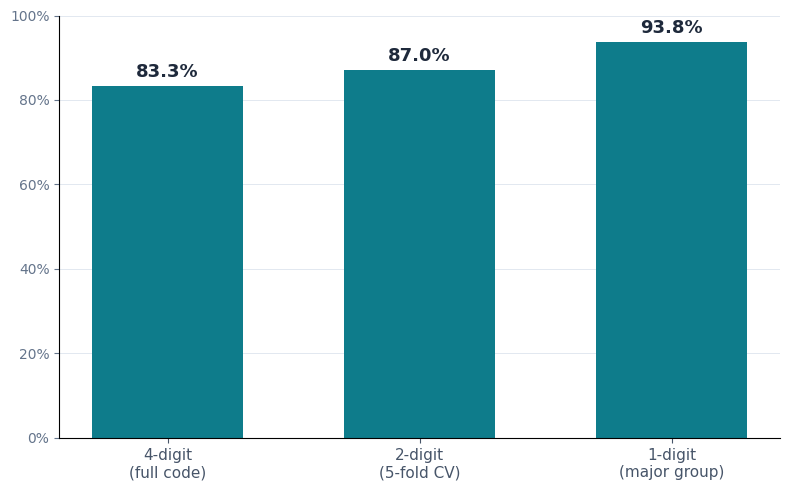

In [31]:
import matplotlib.pyplot as plt

# 1-digit (major group) accuracy, using the same train/test split from Step 7
y_test_major = y_test.astype(str).str[0]
y_pred_major = y_pred.astype(str).str[0]
major_acc = (y_test_major.values == y_pred_major.values).mean()

# Collect the three hierarchy-level scores
levels = ["4-digit\n(full code)", "2-digit\n(5-fold CV)", "1-digit\n(major group)"]
scores = [test_accuracy, cv_scores.mean(), major_acc]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(levels, scores, color="#0E7C8B", width=0.6)

# Percentage labels above each bar
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, score + 0.012,
            f"{score*100:.1f}%", ha="center", va="bottom",
            fontsize=13, fontweight="bold", color="#1E293B")

ax.set_ylim(0, 1.0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v*100)}%"))
ax.set_axisbelow(True)
ax.yaxis.grid(True, color="#E2E8F0", linewidth=0.7)
ax.tick_params(axis="x", colors="#475569", labelsize=11)
ax.tick_params(axis="y", colors="#64748B")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## Step 9: Rule-based baseline (learned from TRAIN only)
Using the consistency analysis from Step 4, learn deterministic rules **only from the training set**
(to avoid leakage) and measure their coverage and accuracy on the test set.

In [24]:
def make_rule_key(df, feature_cols):
    temp = df[feature_cols].copy()
    for col in feature_cols:
        temp[col] = clean_value(temp[col])
    return temp[feature_cols].agg(" | ".join, axis=1)

def learn_rules_from_train(train_df, feature_cols, target_col, min_support, min_purity):
    temp = train_df.copy()
    temp["rule_key"] = make_rule_key(temp, feature_cols)
    temp["target_code"] = temp[target_col].astype(str)
    rule_table = (temp.groupby("rule_key").agg(
        n_rows=("target_code", "size"),
        predicted_code=("target_code", lambda x: x.value_counts().index[0]),
        predicted_code_count=("target_code", lambda x: x.value_counts().iloc[0]),
    ).reset_index())
    rule_table["purity"] = rule_table["predicted_code_count"] / rule_table["n_rows"]
    useful = rule_table.query("n_rows >= @min_support").query("purity >= @min_purity")
    return useful.set_index("rule_key")["predicted_code"].to_dict()

def apply_rule_prediction(df, feature_cols, rule_lookup):
    return make_rule_key(df, feature_cols).map(rule_lookup)

rule_baseline_results = []
for feature_cols in candidate_rules:
    lookup = learn_rules_from_train(train_df, feature_cols, target_col, min_support, min_purity)
    test_rule_pred = apply_rule_prediction(test_df, feature_cols, lookup)
    covered = test_rule_pred.notna()
    acc_cov = ((test_rule_pred[covered].astype(str) == y_test[covered].astype(str)).mean()
               if covered.sum() > 0 else np.nan)
    rule_baseline_results.append({
        "feature_combination": " + ".join(feature_cols),
        "n_rules": len(lookup),
        "test_coverage": round(covered.mean(), 3),
        "acc_on_covered": round(acc_cov, 3) if covered.sum() > 0 else np.nan,
    })
rule_baseline_summary = pd.DataFrame(rule_baseline_results).sort_values(
    ["test_coverage", "acc_on_covered"], ascending=[False, False])
display(rule_baseline_summary)

,feature_combination,n_rules,test_coverage,acc_on_covered
0,EzoAvoda,14,0.208,1.0
5,ShemMachlaka,9,0.208,1.0
7,EzoAvoda + TeurPeula,13,0.208,1.0
8,EzoAvoda + TeurTafkid,14,0.208,1.0
15,EzoAvoda + TeurTafkid + TeurPeula,13,0.208,1.0
4,ShemAvoda,7,0.146,1.0
11,ShemAvoda + EzoAvoda,8,0.146,1.0
12,ShemAvoda + TeurTafkid,7,0.146,1.0
10,SugAvoda + EzoAvoda,11,0.125,1.0
14,SugAvoda + EzoAvoda + TeurPeula,10,0.125,1.0


## Step 10: Hybrid prediction (rule if available, else ML)
If a reliable rule covers a row, use it, otherwise fall back to the ML model.
On such a small set the hybrid may match the ML model, but the design is what scales with more data.

In [27]:
selected_rule_combination = ["EzoAvoda", "TeurPeula"]
selected_lookup = learn_rules_from_train(train_df, selected_rule_combination, target_col, min_support, min_purity)
test_rule_pred = apply_rule_prediction(test_df, selected_rule_combination, selected_lookup)

hybrid_pred = y_pred.astype(str).copy()
rule_mask = test_rule_pred.notna()
hybrid_pred.loc[rule_mask] = test_rule_pred.loc[rule_mask].astype(str)
hybrid_accuracy = accuracy_score(y_test.astype(str), hybrid_pred.astype(str))

print(f"ML accuracy:     {test_accuracy:.3f}")
print(f"Hybrid accuracy: {hybrid_accuracy:.3f}")
print(f"Rule coverage:   {rule_mask.mean():.3f}  ({int(rule_mask.sum())} rows used a rule)")

ML accuracy:     0.833
Hybrid accuracy: 0.833
Rule coverage:   0.208  (10 rows used a rule)


## Step 11: Save the prediction results

In [28]:
out = test_df[[target_col]].copy()
out["ml_prediction"] = y_pred.astype(str).values
out["rule_prediction"] = test_rule_pred.values
out["hybrid_prediction"] = hybrid_pred.values
out["hybrid_correct"] = out[target_col].astype(str) == out["hybrid_prediction"].astype(str)
out["combined_text"] = test_df["combined_text"].values

out.to_csv("predictions_example.csv", index=False, encoding="utf-8-sig")
print("Saved: predictions_example.csv")
display(out.head())

Saved: predictions_example.csv


,SemelMishlachSofi,ml_prediction,rule_prediction,hybrid_prediction,hybrid_correct,combined_text
159,7127,7127,NaN,7127,True,אדרים קבלן בנייה התקנת מזגנים Missing התקנת מזגנים בדירות חדשות טכנאי מזגנים Missing
78,5223,5223,NaN,5223,True,סופר פארם מכירת קוסמטיקה קוסמטיקה וטיפוח Missing יועצת יופי לאנשים מסבירה לאנשים לגבי מוצרים של חברת LOREAL Missing
166,7414,5222,NaN,5222,False,אוסם ייצור חטיפים עבודות חשמל Missing טיפול במערכות חשמל בצפעל Missing Missing
69,3122,3122,NaN,3122,True,אינטל ייצור צ'יפים למחשבים חדר נקי Missing עובד בחדר נקי מפקח על תהליך ייצור צ'יפים Missing
63,2120,2120,NaN,2120,True,"למ""ס איסוף, עיבוד ופרסום נתונים מאקרו כלכלה טיפול בנתוני מאקרו מנהל אגף כנ""ל סגן מנהל אגף"


## Insights and next steps
- **The Classification hierarchy is key**: moving up the level (4 -> 2 -> 1 digits) gives a more stable estimate. Two-stage classification (major group first, then precise code) would handle class imbalance.
- **Consistency analysis (Step 4)**: a few field combinations (e.g. `EzoAvoda + TeurPeula`) map to a single code with high purity - these can be deterministic rules, leaving ML for the ambiguous cases.
- **Labeling noise**: ~10% of manual codes are wrong - a realistic accuracy ceiling.
- **Data limitation**: 191 rows vs 59 classes. Recommendation: more data + a Hebrew language model instead of TF-IDF.